# Introduction to Reinforcement Learning with Q-Learning
## Grid World Navigation Tutorial

In this notebook, we'll implement a Q-learning agent to solve a simple Grid World navigation problem. This tutorial will help you understand the fundamental concepts of reinforcement learning through hands-on implementation.

## 1. Required Imports
First, let's import the necessary libraries for our implementation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

## 2. Creating the Environment

We'll create a `GridWorld` class that represents our environment. This is a 4x4 grid where:
- The agent starts in the bottom-left corner (3,0)
- The goal is in the top-right corner (0,3)
- There are two obstacles at positions (0,0) and (1,1)
- The agent can move in four directions: up, right, down, left

### Key Components:
- State space: 16 possible positions (4x4 grid)
- Action space: 4 possible actions (up, right, down, left)
- Rewards: -1 for each step, +100 for reaching the goal

In [2]:
class GridWorld:
    def __init__(self):
        # Create a 4x4 grid world
        self.height = 4
        self.width = 4
        self.position = (3, 0)  # Start position (bottom-left)
        self.goal = (0, 3)      # Goal position (top-right)
        self.obstacles = [(0, 0), (1, 1)]  # Some obstacles in the grid
        
    def reset(self):
        self.position = (3, 0)
        return self._get_state()
    
    def _get_state(self):
        # Convert position to a single number (0-15)
        return self.position[0] * self.width + self.position[1]
    
    # ------------------------------ START OF YOUR CODE ------------------------------
    def step(self, action):
        # Actions: 0=up, 1=right, 2=down, 3=left
        # Update position based on action
        # Current position is stored in self.position as a tuple (row, col)

        if action == 0:           # up
            row = self.position[0] - 1 # Update row
            col = self.position[1]     # Update col

        elif action == 1:         # right
            row = self.position[0]      # Update row
            col = self.position[1] + 1  # Update col

        elif action == 2:         # down
            row = self.position[0] + 1  # Update row
            col = self.position[1]      # Update col

        elif action == 3:         # left
            row = self.position[0]      # Update row
            col = self.position[1] - 1  # Update col
            
        # Check if new position is valid (not an obstacle)
        # Update position back the self.position.
        if (0 <= row < self.height and 0 <= col < self.width) and (row, col) not in self.obstacles:
            self.position = (row, col)
            
        # Calculate reward and check if done
        reward = -0.1        # Default reward for moving each step
        # Check if the agent reached the goal
        if self.position == self.goal:
            reward = 100    # Reward for reaching the goal
            done = True
        else:
            done = False
            
        return self._get_state(), reward, done
    # ------------------------------ END OF YOUR CODE ------------------------------

    
    def render(self):
        grid = [['□' for _ in range(self.width)] for _ in range(self.height)]
        # Add obstacles
        for obstacle in self.obstacles:
            grid[obstacle[0]][obstacle[1]] = '■'
        # Add goal
        grid[self.goal[0]][self.goal[1]] = 'G'
        # Add current position
        grid[self.position[0]][self.position[1]] = 'A'
        
        # Print grid

        for row in grid:
            print(' '.join(row))
        print()
        time.sleep(0.1)

วิธีสังเกตและวิธีคิด (ดูยังไง?)
1. ส่วนของการเคลื่อนที่ (Actions)
    - ดูจากคอมเมนต์: โค้ดบอกไว้ชัดเจนว่า 0=up, 1=right, 2=down, 3=left ดังนั้นเราจึงเอาตัวเลข 0, 1, 2, 3 ไปใส่หลัง if action == ... ได้เลย
    - การขยับพิกัด (Row, Col): ตำแหน่งปัจจุบันถูกเก็บไว้ใน self.position ซึ่งเป็นคู่ลำดับ (row, col)  โครงสร้างกริด (Grid) ในคอมพิวเตอร์ แถว (row) จะเริ่มจาก 0 ด้านบนและเพิ่มลงล่าง ส่วนคอลัมน์ (col) จะเริ่มจาก 0 ด้านซ้ายและเพิ่มไปขวา
        Up (ขึ้น): แถวต้องลดลง 1 ส่วนคอลัมน์เท่าเดิม  -> row = self.position[0] - 1
        Right (ขวา): แถวเท่าเดิม ส่วนคอลัมน์เพิ่มขึ้น 1  -> col = self.position[1] + 1
        Down (ลง): แถวเพิ่มขึ้น 1 ส่วนคอลัมน์เท่าเดิม  -> row = self.position[0] + 1
        Left (ซ้าย): แถวเท่าเดิม ส่วนคอลัมน์ลดลง 1  -> col = self.position[1] - 1

2. ส่วนของการตรวจสอบตำแหน่งใหม่ (Valid Position)ดูจากคอมเมนต์: Check if new position is valid (not an obstacle)  หมายความว่าตำแหน่งที่จะเดินไปต้อง "ถูกต้อง" และ "ไม่ชนสิ่งกีดขวาง"
    - เราต้องเช็ค 3 อย่าง:
        - ค่าแถวต้องไม่หลุดขอบ: 0 <= row < self.height 
        - ค่าคอลัมน์ต้องไม่หลุดขอบ: 0 <= col < self.width 
        - ต้องไม่เดินไปทับสิ่งกีดขวาง: (row, col) not in self.obstacles 
    - ถ้าเงื่อนไขทั้งหมดเป็นจริง (เดินได้) เราถึงจะอัปเดตตำแหน่งด้วยบรรทัด self.position = (row, col) ตามที่คอมเมนต์บอกให้ Update position back 

3. ส่วนของการให้รางวัล (Reward & Done)
    - ดูจากรายละเอียดของโจทย์: ในเอกสารหน้าแรกหัวข้อ "Key Components" กำหนดไว้ว่า "Rewards: -1 for each step, +100 for reaching the goal" 
    - ดังนั้น Default reward หรือรางวัลในแต่ละก้าวธรรมดาจึงมีค่าเป็น -1 
    เงื่อนไขถึงเส้นชัย (Goal): โค้ดให้เราตรวจสอบว่าถึงเส้นชัยหรือยัง เราจึงใช้ if self.position == self.goal: ถ้าเงื่อนไขนี้เป็นจริง รางวัล (reward) จะกลายเป็น 100 ทันที และสถานะจะจบลง (done = True) 

## 3. Implementing the Q-Learning Agent

Now we'll implement the Q-learning algorithm. Q-learning is a model-free reinforcement learning algorithm that learns a policy telling an agent what action to take under what circumstances.

### Key Components:
- Q-table: Stores action-values for each state-action pair
- Learning rate (α): How much new information overrides old (0.1)
- Discount factor (γ): Importance of future rewards (0.99)
- Exploration rate (ε): Probability of random actions (0.1)

In [3]:
class QLearningAgent:
    def __init__(self, state_size, action_size):
        # Initialize Q-table with small random values instead of zeros
        # This helps break symmetry and encourages initial exploration of all actions
        self.q_table = np.random.uniform(low=0, high=0.01, size=(state_size, action_size))
        self.learning_rate = 0.1
        self.gamma = 0.99
        self.epsilon = 0.2  # Increased from 0.1 to encourage more exploration
        
    def get_action(self, state):
        if np.random.random() < self.epsilon:
            # Print when exploring to verify random actions are being taken
            action = np.random.randint(4)
            return action
        
        # If multiple actions have the same maximum value, choose randomly among them
        # This helps prevent getting stuck in patterns
        actions = np.where(self.q_table[state] == np.max(self.q_table[state]))[0]
        return np.random.choice(actions)
        
    def update(self, state, action, reward, next_state):
        old_value = self.q_table[state, action]
        next_max = np.max(self.q_table[next_state])
        new_value = (1 - self.learning_rate) * old_value + \
                   self.learning_rate * (reward + self.gamma * next_max)
        self.q_table[state, action] = new_value

### Analyze each step of the Q-learning algorithm

In [4]:
def analyze_state(agent, state):
    """Print the Q-values for all actions in a given state"""
    actions = ["UP", "RIGHT", "DOWN", "LEFT"]
    print(f"State {state} Q-values:")
    for i, action in enumerate(actions):
        print(f"  {action}: {agent.q_table[state, i]:.4f}")
    print(f"  Best action: {actions[np.argmax(agent.q_table[state])]}")

## 4. Training Function

Let's create a function to train our agent. This function will:
1. Create the environment and agent
2. Run multiple episodes
3. Track performance metrics
4. Return the trained agent and training history

In [5]:
def train_agent(episodes=100, render=False):
    env = GridWorld()
    agent = QLearningAgent(state_size=16, action_size=4)
    rewards_history = []
    n_steps = []
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        n_step = 0
        while not done:
            if render and episode in (0,900):
                env.render()
                
            # Get action
            action = agent.get_action(state)
            
            # Take action
            next_state, reward, done = env.step(action)
            
            # Update Q-table
            agent.update(state, action, reward, next_state)
            
            total_reward += reward
            state = next_state
            n_step += 1
        
        n_steps.append(n_step)    
        rewards_history.append(total_reward)
        
        if episode % 1 == 0:
            print(f"Episode {episode}, Average Reward: {np.mean(rewards_history[-100:]):.2f}, Number of steps: {n_step}")
    
    return agent, rewards_history, n_steps

## 4.2 Test the initial agent

Now let's test the initial agent without training. We'll run a few episodes and observe the agent's performance.

In [6]:
# Create the test function
def test_agent(agent, episodes=5):
    env = GridWorld()
    
    for episode in range(episodes):
        state = env.reset()
        done = False
        print(f"\nEpisode {episode + 1}")
        
        
        while not done:
            analyze_state(agent, state)
            env.render()
            action = np.argmax(agent.q_table[state])  # Always choose best action
            state, reward, done = env.step(action)
            
        print("Goal reached!")
        time.sleep(1)

## 5.1 Test the agent before training

In [7]:
# Test the initial agent
print("\nTesting trained agent:")
agent = QLearningAgent(state_size=16, action_size=4)
test_agent(agent, episodes=1)


Testing trained agent:

Episode 1
State 12 Q-values:
  UP: 0.0094
  RIGHT: 0.0092
  DOWN: 0.0091
  LEFT: 0.0013
  Best action: UP
■ □ □ G
□ ■ □ □
□ □ □ □
A □ □ □

State 8 Q-values:
  UP: 0.0017
  RIGHT: 0.0035
  DOWN: 0.0043
  LEFT: 0.0057
  Best action: LEFT
■ □ □ G
□ ■ □ □
A □ □ □
□ □ □ □

State 8 Q-values:
  UP: 0.0017
  RIGHT: 0.0035
  DOWN: 0.0043
  LEFT: 0.0057
  Best action: LEFT
■ □ □ G
□ ■ □ □
A □ □ □
□ □ □ □

State 8 Q-values:
  UP: 0.0017
  RIGHT: 0.0035
  DOWN: 0.0043
  LEFT: 0.0057
  Best action: LEFT
■ □ □ G
□ ■ □ □
A □ □ □
□ □ □ □

State 8 Q-values:
  UP: 0.0017
  RIGHT: 0.0035
  DOWN: 0.0043
  LEFT: 0.0057
  Best action: LEFT
■ □ □ G
□ ■ □ □
A □ □ □
□ □ □ □

State 8 Q-values:
  UP: 0.0017
  RIGHT: 0.0035
  DOWN: 0.0043
  LEFT: 0.0057
  Best action: LEFT
■ □ □ G
□ ■ □ □
A □ □ □
□ □ □ □

State 8 Q-values:
  UP: 0.0017
  RIGHT: 0.0035
  DOWN: 0.0043
  LEFT: 0.0057
  Best action: LEFT
■ □ □ G
□ ■ □ □
A □ □ □
□ □ □ □

State 8 Q-values:
  UP: 0.0017
  RIGHT: 0.0035
  DOWN: 0

KeyboardInterrupt: 

## 5.2 Training the Agent

Now let's train our agent and visualize its learning progress. We'll train for 1000 episodes to ensure good convergence.

In [8]:
# Train the agent
agent, rewards, steps = train_agent(episodes=100, render=False)

Episode 0, Average Reward: 96.50, Number of steps: 36
Episode 1, Average Reward: 95.40, Number of steps: 58
Episode 2, Average Reward: 96.50, Number of steps: 14
Episode 3, Average Reward: 96.80, Number of steps: 24
Episode 4, Average Reward: 97.12, Number of steps: 17
Episode 5, Average Reward: 97.43, Number of steps: 11
Episode 6, Average Reward: 97.73, Number of steps: 6
Episode 7, Average Reward: 97.85, Number of steps: 14
Episode 8, Average Reward: 97.94, Number of steps: 14
Episode 9, Average Reward: 98.08, Number of steps: 8
Episode 10, Average Reward: 98.19, Number of steps: 8
Episode 11, Average Reward: 98.28, Number of steps: 9
Episode 12, Average Reward: 98.37, Number of steps: 6
Episode 13, Average Reward: 98.44, Number of steps: 8
Episode 14, Average Reward: 98.51, Number of steps: 6
Episode 15, Average Reward: 98.57, Number of steps: 6
Episode 16, Average Reward: 98.62, Number of steps: 6
Episode 17, Average Reward: 98.66, Number of steps: 8
Episode 18, Average Reward: 98

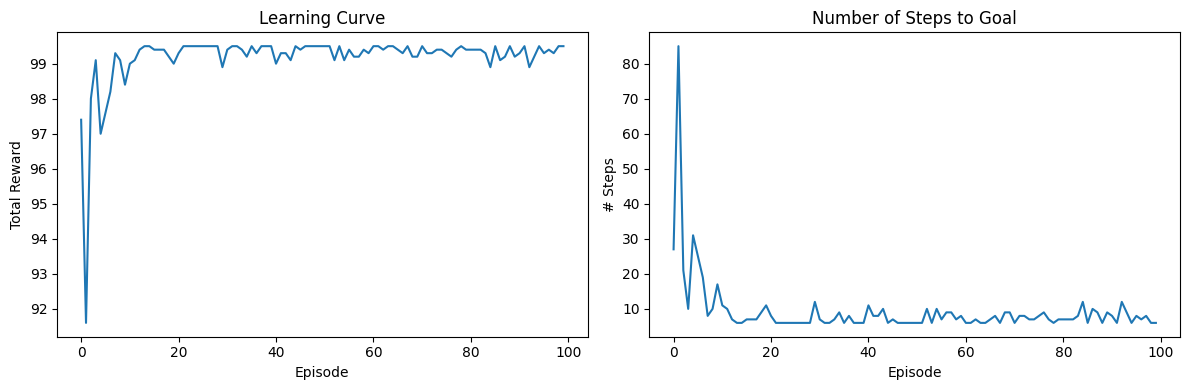

In [ ]:
# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(rewards)
plt.title('Learning Curve')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.subplot(122)
plt.plot(steps)
plt.title('Number of Steps to Goal')
plt.xlabel('Episode')
plt.ylabel('# Steps')
plt.tight_layout()
plt.show()


#### Q-table after training:
Q-table is a 2D array that contains the action-values for each state-action pair. In our case:
- The Q-table will have 16 rows (states) and 4 columns (actions)
- Each cell will contain the action-value for the corresponding state-action pair

Each column in the Q-table represents an action: 
- 0: up
- 1: right
- 2: down
- 3: left
The agent will choose the action with the highest action-value for a given state.
If the values are the same, the agent will choose randomly between them.

Each row in the Q-table represents a state:
- The agent will start in the bottom-left corner (state 12)
- The goal is in the top-right corner (state 0)
- The obstacles are at positions (state 0 and state 5)
- The agent can move in four directions: up, right, down, left


In [ ]:
# Print final Q-table
print("\nFinal Q-table:")
print(agent.q_table)


Final Q-table:
[[ 5.53766414e-03  7.26474411e-03  7.69894237e-03  1.85064893e-03]
 [ 3.73904928e-03  2.87702810e-03  8.13487912e-03  1.17852231e-03]
 [ 2.60169802e-04  1.00098271e+01  5.83583910e-03  5.52270101e-03]
 [ 1.82586619e-03  9.72206482e-03  9.35446634e-03  1.41530130e-04]
 [-7.29672918e-02 -7.76662804e-02 -8.13664202e-02 -7.23539540e-02]
 [ 1.63839983e-03  6.55325736e-03  1.69280983e-03  4.77437350e-03]
 [-8.41851357e-03  5.56350983e+01 -7.52155991e-03  6.03873168e+00]
 [ 1.00006673e+02  4.50573646e+01  4.94057039e+01  1.11170426e+01]
 [-7.82964789e-02  1.82062105e+01 -8.81883350e-02 -7.87432776e-02]
 [-5.64948358e-02  6.32673329e+01  5.01363984e+00  1.63939796e+00]
 [ 8.83546397e+00  9.76366512e+01  6.11802166e+00  1.58902995e+01]
 [ 9.88798385e+01  5.07498311e+01  5.05904270e+00  4.11724688e+01]
 [ 2.10592349e+00  8.80460843e+01  3.02820149e+01  3.16401652e+01]
 [ 7.23224901e+00  9.26614680e+01  2.41252182e+01  1.30801809e+01]
 [ 9.57242085e+01  2.31049580e+00  2.11242120e

## 5.3 Testing the Trained Agent

Let's watch our trained agent navigate the grid. This will help us visualize what the agent has learned.

In [ ]:
# Test the trained agent
print("\nTesting trained agent:")
test_agent(agent, episodes=1)


Testing trained agent:

Episode 1
State 12 Q-values:
  UP: 2.1059
  RIGHT: 88.0461
  DOWN: 30.2820
  LEFT: 31.6402
  Best action: RIGHT
■ □ □ G
□ ■ □ □
□ □ □ □
A □ □ □

State 13 Q-values:
  UP: 7.2322
  RIGHT: 92.6615
  DOWN: 24.1252
  LEFT: 13.0802
  Best action: RIGHT
■ □ □ G
□ ■ □ □
□ □ □ □
□ A □ □

State 14 Q-values:
  UP: 95.7242
  RIGHT: 2.3105
  DOWN: 21.1242
  LEFT: 9.7134
  Best action: UP
■ □ □ G
□ ■ □ □
□ □ □ □
□ □ A □

State 10 Q-values:
  UP: 8.8355
  RIGHT: 97.6367
  DOWN: 6.1180
  LEFT: 15.8903
  Best action: RIGHT
■ □ □ G
□ ■ □ □
□ □ A □
□ □ □ □

State 11 Q-values:
  UP: 98.8798
  RIGHT: 50.7498
  DOWN: 5.0590
  LEFT: 41.1725
  Best action: UP
■ □ □ G
□ ■ □ □
□ □ □ A
□ □ □ □

State 7 Q-values:
  UP: 100.0067
  RIGHT: 45.0574
  DOWN: 49.4057
  LEFT: 11.1170
  Best action: UP
■ □ □ G
□ ■ □ A
□ □ □ □
□ □ □ □

Goal reached!
